# SVR-L Model: BTC Log Realized Variance Forecasting

## Overview
This notebook implements a Linear Support Vector Regression (SVR-L) model to forecast one-day-ahead Bitcoin log realized variance. The model leverages both financial market signals and on-chain blockchain data to capture different dimensions of volatility dynamics.

## Objective
The objective is to predict next-day log realized variance of Bitcoin using a rolling-window Linear SVR framework, and to evaluate forecast performance on a held-out test set using RMSE and QLIKE loss metrics.

## Structure of Notebook
- Section 0: Setup and Reproducibility  
- Section 1: Data Loading  
- Section 2: Feature Construction  
- Section 3: SVR-Linear Model  
- Section 4: Evaluation and Results  

### Section 0: Setting Seed for replicability

In [2]:
import pandas as pd
import numpy as np
import random 
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## Section 1: Data Loading and Preprocessing

In this section, we load the dataset and construct key features required for modeling.

We first transform realized variance into logarithmic scale to stabilise variance and reduce skewness. We then construct lagged features at lags 1, 2, and 3 to capture temporal dependence in volatility dynamics. Additionally, a 30-day rolling mean of log realized variance is included to capture medium-term trends, as motivated by patterns observed in the ACF and PACF plots. Rows with missing values arising from lagging and rolling operations are removed. All features are constructed using only past information to avoid look-ahead bias.

Finally, the dataset is restricted to observations from July 2017 onwards to ensure consistency in the sample period.

In [3]:
df = pd.read_csv('../data/df_with_2regimes.csv')

# take log of realized variance
df['log_realized_variance'] = np.log(df['realized_variance'])
# lag 1,2 andd 3 of log realized variance
df['rv_lag1'] = df['log_realized_variance'].shift(1)
df['rv_lag2'] = df['log_realized_variance'].shift(2)
df['rv_lag3'] = df['log_realized_variance'].shift(3)

# rolling mean of log realized variance over the past 30 days
df['rv_rolling_mean_30'] = df['log_realized_variance'].rolling(window=30).mean() 

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
#df.head(30)
#df.info()
# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
#print(df.isna().sum())

## Section 2: Feature Construction
The SVR model is provided with an extended set of features capturing multiple dimensions of market dynamics.

In [4]:
svr_features = ["log_return", "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg", 
    "log_realized_variance", "rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]

#len(svr_features)

In [10]:
# split data into train, evaluation and out of sample test sets 60/25/15
n= len(df)

train_size = int(n * 0.6)
eval_size = int(n * 0.25)

train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size 
eval_end_idx = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx = n

train_df = df.iloc[train_start_idx:train_end_idx].copy()
eval_df = df.iloc[eval_start_idx:eval_end_idx].copy()
test_df = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set: {len(train_df)} rows")
print(f"Evaluation set: {len(eval_df)} rows")
print(f"Test set: {len(test_df)} rows")

Train set: 1875 rows
Evaluation set: 781 rows
Test set: 469 rows


## Section 3: SVR-Linear Model

In this section, we construct a one-stage forecasting model using a linear Support Vector Regression (SVR). The model is used to generate one-step-ahead forecasts of log realized variance based on a rich set of features capturing volatility dynamics, market conditions, and blockchain activity.

The following cells contain several key helper functions that implement model estimation, one-step-ahead forecasting, and the rolling-window evaluation procedure.

In [11]:
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler

In [12]:
def one_step_svr_forecast(fitted_svr, x_next):
    
    if fitted_svr is None:
        return np.nan

    try:
        x_next = np.asarray(x_next).reshape(1, -1)
        pred = fitted_svr.predict(x_next)[0]
        return float(pred)
    except Exception:
        return np.nan

    
def fit_svr_safe(X_train, y_train, C=1.0, epsilon=1e-4, min_obs=100):
    if len(X_train) < min_obs:
        return None

    try:
        model = LinearSVR(C=C, epsilon=epsilon, dual=True, max_iter=20000)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        print("LinearSVR fit failed:", e)
        return None

In [13]:
def rolling_svr_linear_eval(
    df_full,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    scale_window=365,
    C=1.0,
    epsilon=1e-4,
    min_obs=200
):
    results = []

    df = df_full.copy()

    # target is next day's realized variance
    df["target_lead1"] = df[realized_var_col].shift(-1)

    feature_cols = x_feature_cols

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date = next_row[date_col]

        # training rows exclude row t
        window_df = df.iloc[max(0, t - rolling_window + 1): t].copy()

        needed_cols = feature_cols + ["target_lead1"]
        train_df = window_df[needed_cols].dropna()

        if len(train_df) < min_obs:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_target": next_row[realized_var_col],
                "pred_target": np.nan
            })
            continue
        
        # scale features using past data up to t, excluding t
        scaler_hist = window_df[feature_cols].dropna().iloc[-min(scale_window, len(window_df[feature_cols].dropna())):].copy()

        if len(scaler_hist) == 0:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_target": next_row[realized_var_col],
                "pred_target": np.nan
            })
            continue

        scaler = StandardScaler()
        scaler.fit(scaler_hist)

        # scale training features
        X_train = scaler.transform(train_df[feature_cols])
        y_train = train_df["target_lead1"].values

        model = fit_svr_safe(
            X_train=X_train,
            y_train=y_train,
            C=C,
            epsilon=epsilon,
            min_obs=min_obs
        )

        x_t = current_row[feature_cols]

        if x_t.isna().any():
            pred = np.nan
        else:
            x_t_df = x_t.to_frame().T
            x_t_scaled = scaler.transform(x_t_df)
            pred = one_step_svr_forecast(model, x_t_scaled[0])

        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_target": next_row[realized_var_col],
            "pred_target": pred
        })

    return pd.DataFrame(results)

## Miscellaneous
In this section, we define helper functions for computing RMSE and QLIKE, which are used to evaluate model performance.

In [5]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 


## Section 5: Evaluation and Results

With the necessary helper functions defined above, we proceed to tune the models and evaluate their out-of-sample performance on the test set. The evaluation is structured as follows:

1. Data sample splitting into training, validation, and test sets  
2. Hyperparameter tuning of the Linear SVR model
3. Final model estimation using both training and validation data, followed by a rolling-window evaluation to generate one-step-ahead forecasts on the out-of-sample test set  

In [ ]:
# split data into train, evaluation and out of sample test sets 60/25/15
n= len(df)

train_size = int(n * 0.6)
eval_size = int(n * 0.25)

train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size 
eval_end_idx = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx = n

train_df = df.iloc[train_start_idx:train_end_idx].copy()
eval_df = df.iloc[eval_start_idx:eval_end_idx].copy()
test_df = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set: {len(train_df)} rows")
print(f"Evaluation set: {len(eval_df)} rows")
print(f"Test set: {len(test_df)} rows")

In [6]:
from itertools import product  

### Hyperparameter tuning

- **Hyperparameters tuned:**  
  - Regularisation parameter $C \in \{0.1, 1.0, 10.0\}$  
  - ε-insensitive loss parameter $\epsilon \in \{10^{-4}, 10^{-3}, 10^{-2}\}$  
  - Total of 9 configurations

- **Selection criterion:** The best configuration is selected based on the lowest QLIKE value on the evaluation set.

In [16]:
svr_grid = {
    "kernel": ["linear"],
    "C": [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2]
}

svr_param_grid = []
for kernel, C, epsilon in product(
    svr_grid["kernel"],
    svr_grid["C"],
    svr_grid["epsilon"]
):
    svr_param_grid.append({
        "kernel": kernel,
        "C": C,
        "epsilon": epsilon
    })
print(f"Total SVR configs: {len(svr_param_grid)}")

Total SVR configs: 9


In [ ]:
svr_results = []

for i, params in enumerate(svr_param_grid, 1):
    kernel = params["kernel"]
    C = params["C"]
    epsilon = params["epsilon"]

    print(f"\n[{i}/{len(svr_param_grid)}] Testing SVR: {params}")

    try:
        eval_svr = rolling_svr_linear_eval(
            df_full=df,
            start_idx=eval_start_idx,
            end_idx=eval_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=365,
            C=C,
            epsilon=epsilon,
            min_obs=100
        )

        # convert log variance back to variance for QLIKE
        eval_svr["actual_var"] = np.exp(eval_svr["actual_target"])
        eval_svr["pred_var"]   = np.exp(eval_svr["pred_target"])

        eval_rmse = rmse(eval_svr["actual_target"], eval_svr["pred_target"])
        eval_qlike = qlike(eval_svr["actual_var"], eval_svr["pred_var"])
        n_eval_forecasts = eval_svr["pred_target"].notna().sum()

        svr_results.append({
            **params,
            "eval_rmse": eval_rmse,
            "eval_qlike": eval_qlike,
            "n_eval_forecasts": n_eval_forecasts
        })

    except Exception as e:
        svr_results.append({
            **params,
            "eval_rmse": np.nan,
            "eval_qlike": np.nan,
            "n_eval_forecasts": 0,
            "error": str(e)
        })

svr_results_df = pd.DataFrame(svr_results).sort_values("eval_qlike")
#print(svr_results_df.head())


[1/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001}

[2/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001}

[3/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

[4/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.0001}

[5/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.001}

[6/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01}

[7/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.0001}


/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.w


[8/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.001}


/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.w


[9/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.01}


/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.w

   kernel    C  epsilon  eval_rmse  eval_qlike  n_eval_forecasts
1  linear  0.1   0.0010   1.089750    0.541918               781
0  linear  0.1   0.0001   1.089982    0.541988               781
2  linear  0.1   0.0100   1.090859    0.542841               781
5  linear  1.0   0.0100   1.068204    0.647819               781
4  linear  1.0   0.0010   1.068091    0.649156               781


/Users/jasonlow/Desktop/DSE4211-GRP13/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
svr_results_df = pd.DataFrame(svr_results).sort_values("eval_qlike")
#print(svr_results_df.head())

   kernel    C  epsilon  eval_rmse  eval_qlike  n_eval_forecasts
1  linear  0.1   0.0010   1.089750    0.541918               781
0  linear  0.1   0.0001   1.089982    0.541988               781
2  linear  0.1   0.0100   1.090859    0.542841               781
5  linear  1.0   0.0100   1.068204    0.647819               781
4  linear  1.0   0.0010   1.068091    0.649156               781


In [ ]:
best_svr_params = svr_results_df.iloc[0].to_dict()
#print(best_svr_params)

{'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001, 'eval_rmse': 1.0897496492827887, 'eval_qlike': 0.5419180923007676, 'n_eval_forecasts': 781}


## Out of sample testing 

In [21]:
test_regime_start_idx = max(0, test_start_idx - 365)

test_svr = rolling_svr_linear_eval(
    df_full=df,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=best_svr_params["C"],
    epsilon=best_svr_params["epsilon"],
    min_obs=100
)


test_rmse = rmse(test_svr["actual_target"], test_svr["pred_target"])


# Convert back to variance scale for QLIKE
test_svr["actual_var"] = np.maximum(np.exp(test_svr["actual_target"]), 1e-12)
test_svr["pred_var"]   = np.maximum(np.exp(test_svr["pred_target"]), 1e-12)

test_qlike = qlike(test_svr["actual_var"], test_svr["pred_var"])
test_rsme_variance = rmse(test_svr["actual_var"], test_svr["pred_var"])

print("Final Test RMSE :", test_rmse)
print("Final Test RMSE (var scale):", test_rsme_variance)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_svr["pred_target"].notna().sum())



Final Test RMSE : 1.0217892392686665
Final Test RMSE (var scale): 0.0006181252597298871
Final Test QLIKE: 0.4110958060087329
Number of test forecasts: 469


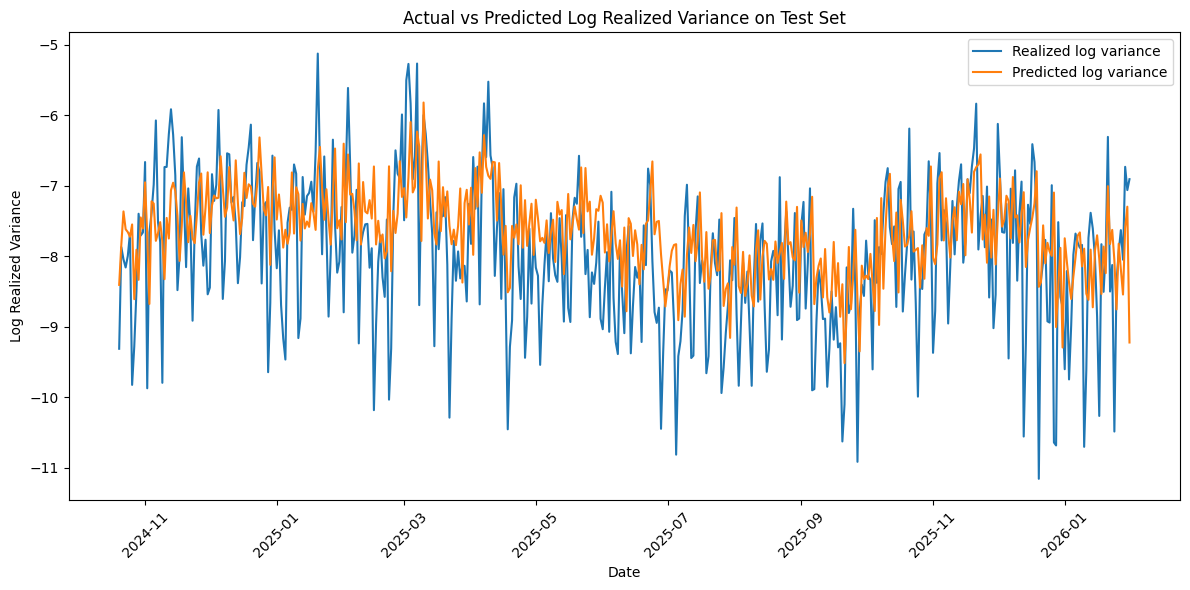

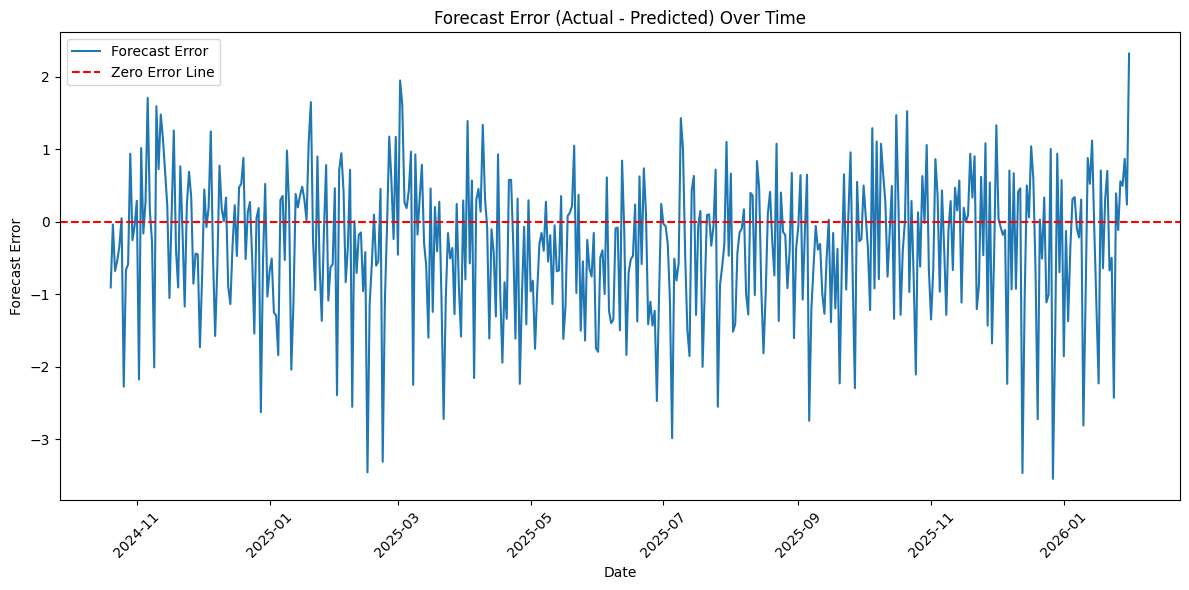

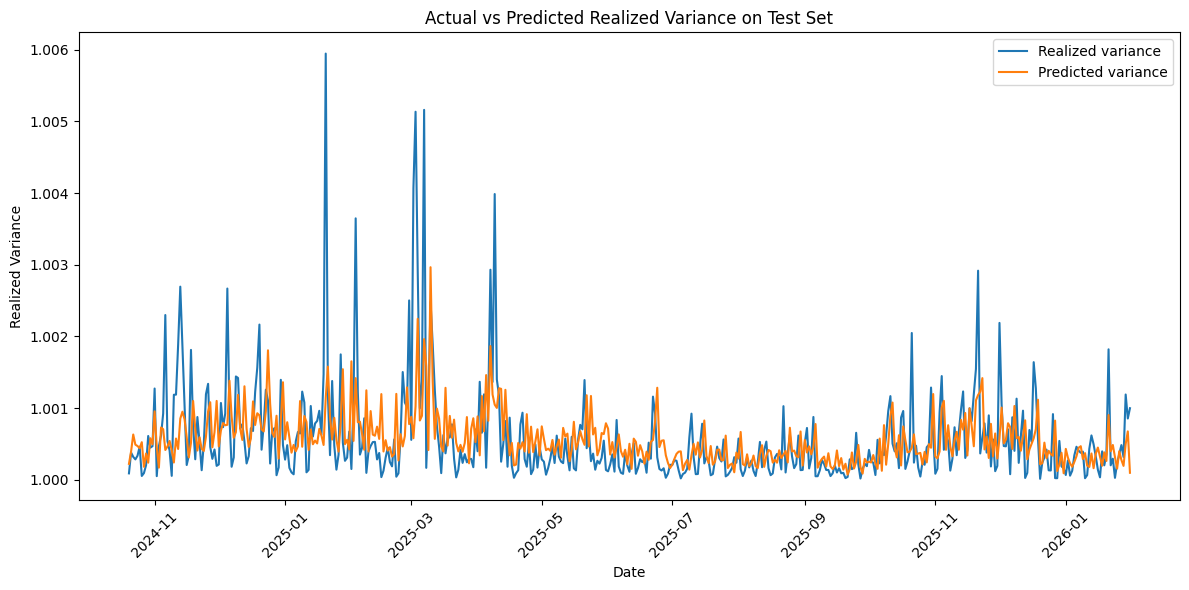

In [25]:
# plot actual vs predicted log variance on test set
import matplotlib.pyplot as plt
test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["actual_target"], label="Realized log variance")
plt.plot(test_svr["date"], test_svr["pred_target"], label="Predicted log variance")
plt.title("Actual vs Predicted Log Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Log Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_svr['date'] = pd.to_datetime(test_svr['date'])
test_svr['error'] = test_svr["actual_target"] - test_svr["pred_target"]
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], np.exp(test_svr["actual_var"]), label="Realized variance")
plt.plot(test_svr["date"], np.exp(test_svr["pred_var"]), label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# export results to csv
#test_svr.to_csv("results/svr_test_results.csv", index=False)